In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
odds =pd.read_parquet("data/processed/odds.parquet")
point_by_point =pd.read_parquet("data/processed/point_by_point.parquet")
statistics =pd.read_parquet("data/processed/statistics.parquet")
tennis_power =pd.read_parquet("data/processed/tennis_power.parquet")
votes =pd.read_parquet("data/processed/votes.parquet")
MatchAwayScoreInfo=pd.read_parquet("data/processed/match_away_score_info.parquet")
MatchHomeScoreInfo=pd.read_parquet("data/processed/match_home_score_info.parquet")
MatchEventInfo=pd.read_parquet("data/processed/match_event_info.parquet")
MatchAwayTeamInfo=pd.read_parquet("data/processed/MatchAwayTeamInfo.parquet")
MatchHomeTeamInfo=pd.read_parquet("data/processed/MatchHomeTeamInfo.parquet")
MatchRoundInfo=pd.read_parquet("data/processed/MatchRoundInfo.parquet")
MatchSeasonInfo=pd.read_parquet("data/processed/MatchSeasonInfo.parquet")
MatchTimeInfo=pd.read_parquet("data/processed/MatchTimeInfo.parquet")
MatchTournamentInfo=pd.read_parquet("data/processed/MatchTournamentInfo.parquet")
MatchVenueInfo=pd.read_parquet("data/processed/MatchVenueInfo.parquet")

### Question seven

In [8]:
statistics[statistics.astype(str).apply(lambda row:row.str.contains("aces",case=False).any(),axis=1)].head()

,match_id,period,statistic_category_name,statistic_name,home_stat,away_stat,compare_code,statistic_type,value_type,home_value,away_value,home_total,away_total,date
0,11998445,ALL,service,aces,12,6,1,positive,event,12,6,NaN,NaN,20240201
20,11998445,1ST,service,aces,2,3,2,positive,event,2,3,NaN,NaN,20240201
37,11998445,2ND,service,aces,6,3,1,positive,event,6,3,NaN,NaN,20240201
54,11998445,3RD,service,aces,4,0,1,positive,event,4,0,NaN,NaN,20240201
71,11998446,ALL,service,aces,6,3,1,positive,event,6,3,NaN,NaN,20240201


The dataset contains four period categories:

- **1ST** — First period
- **2ND** — Second period
- **3RD** — Third period
- **ALL** — Total of the 1st, 2nd, and 3rd periods

For this analysis, we will filter the dataset and keep only the records where the period is **ALL**.

In [20]:
aces= statistics[(statistics["statistic_name"].str.lower() == "aces") & (statistics["period"]=="ALL")].copy()
aces

,match_id,period,statistic_category_name,statistic_name,home_stat,away_stat,compare_code,statistic_type,value_type,home_value,away_value,home_total,away_total,date
0,11998445,ALL,service,aces,12,6,1,positive,event,12,6,NaN,NaN,20240201
71,11998446,ALL,service,aces,6,3,1,positive,event,6,3,NaN,NaN,20240201
125,11998447,ALL,service,aces,8,4,1,positive,event,8,4,NaN,NaN,20240201
178,11998448,ALL,service,aces,4,0,1,positive,event,4,0,NaN,NaN,20240201
232,11998449,ALL,service,aces,6,4,1,positive,event,6,4,NaN,NaN,20240201
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1357965,12213482,ALL,service,aces,0,1,2,positive,event,0,1,NaN,NaN,20240331
1358019,12213483,ALL,service,aces,0,0,3,positive,event,0,0,NaN,NaN,20240331
1358073,12213484,ALL,service,aces,1,0,1,positive,event,1,0,NaN,NaN,20240331
1358127,12213486,ALL,service,aces,0,1,2,positive,event,0,1,NaN,NaN,20240331


In [46]:
aces["home_value"] = pd.to_numeric(aces["home_value"], errors="coerce")
aces["away_value"] = pd.to_numeric(aces["away_value"], errors="coerce")

In [22]:
aces.duplicated().sum()

0

In [28]:
ace_check = aces.groupby("match_id").agg(
    rows=("match_id", "size"),
    home_values=("home_value", "nunique"),
    away_values=("away_value", "nunique")
)

ace_check.sort_values("rows", ascending=False).head(20)

,rows,home_values,away_values
match_id,,,
12063583,4,1,1
12063599,4,1,1
12063611,4,1,1
12063615,4,1,1
12063589,4,1,1
12063588,4,1,1
12063587,4,1,1
12195781,4,1,1
12063582,4,1,1


In this step, we check each `match_id` to see how many times it is repeated.
For each `match_id`, we also check the number of **unique (`nunique`) values** for:
- `home_value`
- `away_value`
This helps us identify whether each match has one unique home value and one unique away value, or whether there are multiple different values for the same match.

In [29]:
problem_aces = ace_check[
    (ace_check["home_values"] > 1) |
    (ace_check["away_values"] > 1)
]

print("Matches with different ace values:", len(problem_aces))
problem_aces.head()

Matches with different ace values: 1126


,rows,home_values,away_values
match_id,,,
12056874,2,2,1
12058641,2,2,2
12058688,2,2,1
12058689,2,1,2
12058702,2,1,2


In [31]:
aces[aces["match_id"] == 12056874].T

,199921,214324
match_id,12056874,12056874
period,ALL,ALL
statistic_category_name,service,service
statistic_name,aces,aces
home_stat,0,1
away_stat,0,0
compare_code,3,1
statistic_type,positive,positive
value_type,event,event
home_value,0,1


it's example to understand which columns can be different when match_id and home_value and away_value are the same. in this case `date` and `compare_code` and `home_value` are different.

In [43]:
aces[["home_value", "away_value"]].isna().sum()

home_value    0
away_value    0
dtype: int64

In [45]:
aces["date"] = pd.to_datetime(aces["date"])
aces[["match_id", "home_value", "away_value", "date"]].head()

,match_id,home_value,away_value,date
0,11998445,12,6,2024-02-01
71,11998446,6,3,2024-02-01
125,11998447,8,4,2024-02-01
178,11998448,4,0,2024-02-01
232,11998449,6,4,2024-02-01


In [47]:
latest_date = aces.groupby("match_id")["date"].transform("max")
aces_latest = aces[aces["date"] == latest_date].copy()

In [48]:
print("Latest-date rows:", len(aces_latest))
print("Unique matches:", aces_latest["match_id"].nunique())

Latest-date rows: 11389
Unique matches: 11389


The most reasonable rule is to keep the record with the latest date, but I would verify that assumption first.

In [49]:
latest_duplicates = aces_latest[aces_latest["match_id"].duplicated(keep=False)]

print("Rows with repeated match_id:", len(latest_duplicates))
print("Matches repeated:",latest_duplicates["match_id"].nunique())

Rows with repeated match_id: 0
Matches repeated: 0


In [52]:
aces_final=(aces_latest.drop_duplicates(subset="match_id").copy())
aces_final["total_aces"]=(aces_final["home_value"]+aces_final["away_value"])
aces_final[["match_id","home_value","away_value","total_aces"]].head()

,match_id,home_value,away_value,total_aces
178,11998448,4,0,4
232,11998449,6,4,10
286,11998450,16,10,26
356,11998451,7,5,12
802,11998672,4,9,13


In [54]:
average_aces=aces_final["total_aces"].mean()
print(f"Average number of aces per match: {average_aces:.2f}")

Average number of aces per match: 5.39


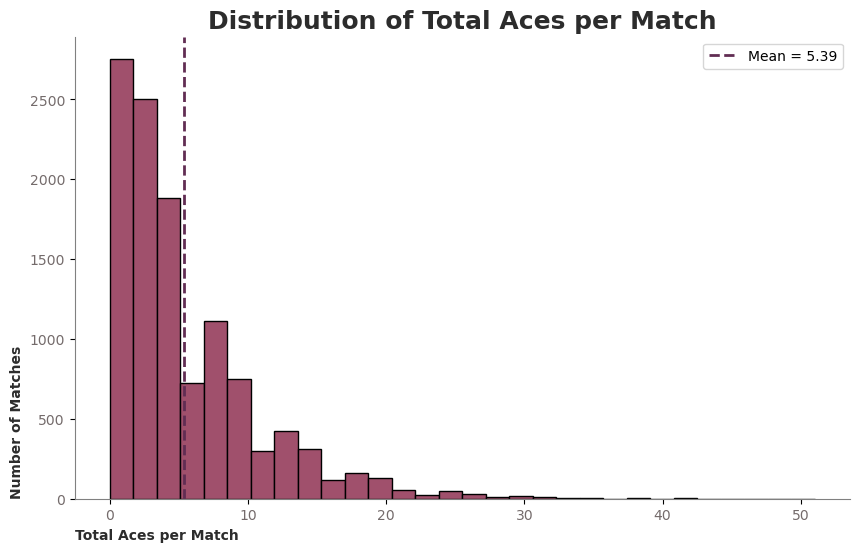

In [65]:
plt.figure(figsize=(10,6))
plt.hist(aces_final["total_aces"],color="#A0506C",bins=30,edgecolor="black")
plt.axvline(average_aces,linestyle="--",linewidth=2,color="#612D53",label=f"Mean = {average_aces:.2f}")
plt.xlabel("Total Aces per Match",loc="left",color="#2C2C2C",weight="bold")
plt.ylabel("Number of Matches",loc="bottom",color="#2C2C2C",weight="bold")
plt.xticks(color="#746B6B")
plt.yticks(color="#746B6B")
plt.title("Distribution of Total Aces per Match",color="#2C2C2C",weight="bold",fontsize=18)
ax=plt.gca()
ax.spines[["top","right"]].set_visible(False)
ax.spines[["bottom","left"]].set_color("gray")
plt.legend()
plt.show()

### Question Eight

In [51]:
statistics[statistics["statistic_name"].str.contains("fault",case=False,na=False)]["statistic_name"].unique()

array(['double_faults'], dtype=object)

In [52]:
statistics[statistics.astype(str).apply(lambda row:row.str.contains("double_faults",case=False).any(),axis=1)].head()

,match_id,period,statistic_category_name,statistic_name,home_stat,away_stat,compare_code,statistic_type,value_type,home_value,away_value,home_total,away_total,date
1,11998445,ALL,service,double_faults,2,7,2,negative,event,2,7,NaN,NaN,20240201
21,11998445,1ST,service,double_faults,1,2,2,negative,event,1,2,NaN,NaN,20240201
38,11998445,2ND,service,double_faults,1,2,2,negative,event,1,2,NaN,NaN,20240201
55,11998445,3RD,service,double_faults,0,3,2,negative,event,0,3,NaN,NaN,20240201
72,11998446,ALL,service,double_faults,2,1,1,negative,event,2,1,NaN,NaN,20240201


In [53]:
faults = statistics[(statistics["statistic_name"]=="double_faults")&
                          (statistics["period"]=="ALL")].copy()
faults

,match_id,period,statistic_category_name,statistic_name,home_stat,away_stat,compare_code,statistic_type,value_type,home_value,away_value,home_total,away_total,date
1,11998445,ALL,service,double_faults,2,7,2,negative,event,2,7,NaN,NaN,20240201
72,11998446,ALL,service,double_faults,2,1,1,negative,event,2,1,NaN,NaN,20240201
126,11998447,ALL,service,double_faults,0,5,2,negative,event,0,5,NaN,NaN,20240201
179,11998448,ALL,service,double_faults,2,2,3,negative,event,2,2,NaN,NaN,20240201
233,11998449,ALL,service,double_faults,2,3,2,negative,event,2,3,NaN,NaN,20240201
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1357966,12213482,ALL,service,double_faults,0,6,2,negative,event,0,6,NaN,NaN,20240331
1358020,12213483,ALL,service,double_faults,2,4,2,negative,event,2,4,NaN,NaN,20240331
1358074,12213484,ALL,service,double_faults,2,7,2,negative,event,2,7,NaN,NaN,20240331
1358128,12213486,ALL,service,double_faults,1,13,2,negative,event,1,13,NaN,NaN,20240331


In [54]:
fault_check = faults.groupby("match_id").agg(
    rows=("match_id", "size"),
    home_values=("home_value", "nunique"),
    away_values=("away_value", "nunique")
)

fault_check.sort_values("rows", ascending=False).head(20)

,rows,home_values,away_values
match_id,,,
12063583,4,1,1
12063599,4,1,1
12063611,4,1,1
12063615,4,1,1
12063589,4,1,1
12063588,4,1,1
12063587,4,1,1
12195781,4,1,1
12063582,4,1,1


In [55]:
faults["home_value"] = pd.to_numeric(faults["home_value"], errors="coerce")
faults["away_value"] = pd.to_numeric(faults["away_value"], errors="coerce")
faults["date"] = pd.to_datetime(faults["date"])

In [56]:
double_faults_final=(faults.sort_values(["match_id","date"]).drop_duplicates(subset="match_id",keep="last").copy())
print("Rows:", len(double_faults_final))
print("Unique matches:",double_faults_final["match_id"].nunique())

Rows: 11389
Unique matches: 11389


In [57]:
home_gender = MatchHomeTeamInfo[
    ["match_id", "gender"]
].drop_duplicates()

away_gender = MatchAwayTeamInfo[
    ["match_id", "gender"]
].drop_duplicates()

gender_check = home_gender.merge(
    away_gender,
    on="match_id",
    suffixes=("_home", "_away")
)
df_double = double_faults_final.merge(gender_check,on="match_id",how="left")
df_double

,match_id,period,statistic_category_name,statistic_name,home_stat,away_stat,compare_code,statistic_type,value_type,home_value,away_value,home_total,away_total,date,gender_home,gender_away
0,11998445,ALL,service,double_faults,2,7,2,negative,event,2,7,NaN,NaN,2024-02-02,M,M
1,11998446,ALL,service,double_faults,2,1,1,negative,event,2,1,NaN,NaN,2024-02-02,M,M
2,11998447,ALL,service,double_faults,0,5,2,negative,event,0,5,NaN,NaN,2024-02-02,M,M
3,11998448,ALL,service,double_faults,2,2,3,negative,event,2,2,NaN,NaN,2024-02-01,M,M
4,11998449,ALL,service,double_faults,2,3,2,negative,event,2,3,NaN,NaN,2024-02-01,M,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11384,12213482,ALL,service,double_faults,0,6,2,negative,event,0,6,NaN,NaN,2024-03-31,NaN,NaN
11385,12213483,ALL,service,double_faults,2,4,2,negative,event,2,4,NaN,NaN,2024-03-31,NaN,NaN
11386,12213484,ALL,service,double_faults,2,7,2,negative,event,2,7,NaN,NaN,2024-03-31,NaN,NaN
11387,12213486,ALL,service,double_faults,1,13,2,negative,event,1,13,NaN,NaN,2024-03-31,NaN,NaN


In [93]:
home_players = df_double[["match_id", "gender_home", "home_value"]].copy()
home_players.columns = ["match_id", "gender", "double_faults"]

away_players = df_double[["match_id", "gender_away", "away_value"]].copy()
away_players.columns = ["match_id", "gender", "double_faults"]

In [97]:
double_faults_gender = pd.concat([home_players, away_players],ignore_index=True)
double_faults_gender = double_faults_gender.dropna(subset=["gender", "double_faults"])
result=(double_faults_gender.groupby("gender")["double_faults"].agg(["count","mean","median","std"]))
result

,count,mean,median,std
gender,,,,
F,7906,3.506324,3.0,2.843775
M,10046,2.696695,2.0,2.274905


Female players recorded a higher average number of double faults (3.51) than male players (2.70). The median was also higher for females (3 vs. 2), suggesting that double faults tend to be more frequent among female players in this dataset.

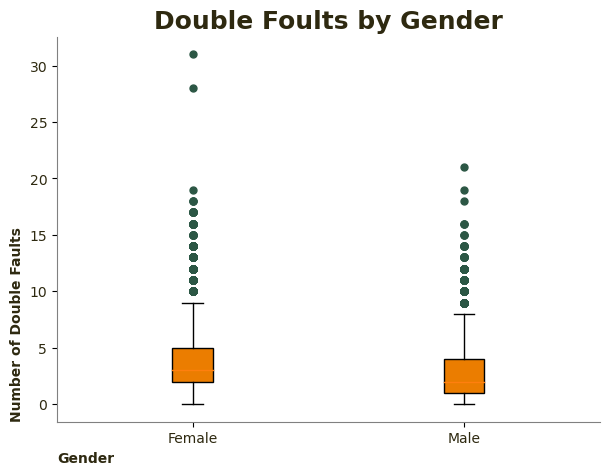

In [109]:
female=double_faults_gender[double_faults_gender["gender"] =="F"]["double_faults"]
male=double_faults_gender[double_faults_gender["gender"]=="M"]["double_faults"]
plt.figure(figsize=(7,5))
bp=plt.boxplot([female,male],labels=["Female","Male"],patch_artist=True,flierprops={"marker":"o","markerfacecolor":"#2C5745","markeredgecolor":"#2C5745","markersize":5})
bp["boxes"][0].set_facecolor("#EB7D00")
bp["boxes"][1].set_facecolor("#EB7D00")

plt.xlabel("Gender",loc="left",color="#2E2910",weight="bold")
plt.ylabel("Number of Double Faults",loc="bottom",color="#2E2910",weight="bold")
plt.title("Double Foults by Gender",weight="bold",color="#2E2910",fontsize=18)
plt.xticks(color="#2E2910")
plt.yticks(color="#2E2910")
ax=plt.gca()
ax.spines[["top","right"]].set_visible(False)
ax.spines[["bottom","left"]].set_color("gray")

plt.show()

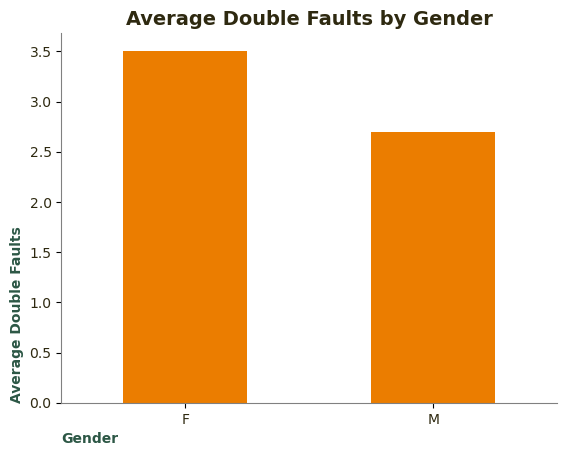

In [118]:
mean_gender=(double_faults_gender.groupby("gender")["double_faults"].mean())
mean_gender.plot(kind="bar",color="#EB7D00")
plt.xlabel("Gender",loc="left",color="#2C5745",weight="bold")
plt.ylabel("Average Double Faults",loc="bottom",color="#2C5745",weight="bold")
plt.title("Average Double Faults by Gender",weight="bold",fontsize=14,color="#2E2910")
plt.xticks(rotation=0,color="#2E2910")
plt.yticks(color="#2E2910")
ax=plt.gca()
ax.spines[["top","right"]].set_visible(False)
ax.spines[["bottom","left"]].set_color("gray")
plt.show()

### Question Nine

In [ ]:
final_round= MatchRoundInfo[MatchRoundInfo["name"]=="Final"].copy()
final_round["date"] = pd.to_datetime(final_round["date"])
final_round = (final_round.sort_values(["match_id", "date"]).drop_duplicates("match_id", keep="last").copy())

tournaments = MatchTournamentInfo[["match_id","tournament_id","tournament_name","date"]].copy()
tournaments["date"] = pd.to_datetime(tournaments["date"])
tournaments = (tournaments.sort_values(["match_id", "date"]).drop_duplicates("match_id", keep="last").copy())

events =MatchEventInfo[["match_id","winner_code","start_datetime","date"]].copy()
events["date"] = pd.to_datetime(events["date"])
events = (events.sort_values(["match_id", "date"]).drop_duplicates("match_id", keep="last").copy())

home_player=MatchHomeTeamInfo[["match_id","player_id","full_name","date"]].copy()
home_players["date"] = pd.to_datetime(home_players["date"])
home_player = home_player.sort_values(["match_id","date"]).drop_duplicates("match_id",keep="last").rename(columns={"player_id":"home_player_id","full_name":"home_player"})

away_player=MatchAwayTeamInfo[["match_id","player_id","full_name","date"]].copy()
away_players["date"] = pd.to_datetime(away_players["date"])
away_player = away_player.sort_values(["match_id","date"]).drop_duplicates("match_id",keep="last").rename(columns={"player_id":"away_player_id","full_name":"away_player"})

In [151]:
finals = (final_round[["match_id"]]
          .merge(events,on="match_id",how="left")
          .merge(tournaments[["match_id","tournament_id","tournament_name"]],on="match_id",how="left")
          .merge(home_player[["match_id","home_player_id","home_player"]],on="match_id",how="left")
          .merge(away_player[["match_id","away_player_id","away_player"]],on="match_id",how="left")
          )
finals.head()

,match_id,winner_code,start_datetime,date,tournament_id,tournament_name,home_player_id,home_player,away_player_id,away_player
0,11998455,2.0,1707055200,2024-02-05,126168,"Montpellier, France",64580.0,"Ćorić, Borna",163480.0,"Bublik, Alexander"
1,11998663,1.0,1707012000,2024-02-04,126174,"Burnie 1, Australia",79467.0,"Jasika, Omar",58369.0,"Bolt, Alex"
2,11998773,1.0,1707069600,2024-02-05,126179,"Cleveland, USA",210490.0,"Kypson, Patrick",334293.0,"Quinn, Ethan"
3,11999016,1.0,1707051600,2024-02-05,126192,"Koblenz, Germany",200159.0,"Rodionov, Jurij",235576.0,"Nakashima, Brandon"
4,11999218,2.0,1707055200,2024-02-05,126196,"Piracicaba, Brazil",54573.0,"Coria, Federico",196122.0,"Ugo Carabelli, Camilo"


In [153]:
finals["winner_id"] = np.where(finals["winner_code"] == 1,finals["home_player_id"], np.where(finals["winner_code"]==2,finals["away_player_id"],np.nan))
finals["winner"] = np.where(finals["winner_code"] == 1,finals["home_player"], np.where(finals["winner_code"]==2,finals["away_player"],np.nan))


In [155]:
finals["match_date"]=pd.to_datetime(finals["start_datetime"],unit="s")
finals["month"]=finals["match_date"].dt.to_period("M")
titles=finals.dropna(subset=["winner_id","month","tournament_id"]).copy()
monthly_titles=(titles.groupby(["winner_id","winner","month"])["tournament_id"].nunique().reset_index(name="tournament_won"))

In [156]:
result = monthly_titles.sort_values("tournament_won",ascending=False)
result.head(20)

,winner_id,winner,month,tournament_won
188,341818.0,"Faria, Jaime",2024-03,3
196,372311.0,"Nicod, Jakub",2024-03,3
135,230049.0,"Jianu, Filip Cristian",2024-03,3
76,152766.0,"Helgo, Malene",2024-03,3
14,50901.0,"Popko, Dmitry",2024-02,3
107,202572.0,"Gengel, Marek",2024-02,3
58,111857.0,"Ursu, Vadym",2024-03,2
201,381430.0,"Valentova, Tereza",2024-02,2
28,63642.0,"Kwiatkowski, Thai-Son",2024-03,2
163,289173.0,"Hussey, Giles",2024-03,2


Faria, Jaime won the most tournaments in a single month, winning 3 tournaments in March 2024. And the Popko, Dmitry won the most tournaments in a single month, winning 3 tournaments in February 2024

In [ ]:
top10 = result.head(10).copy()
top10["label"] = (top10["winner"].astype(str) + " (" + top10["month"].astype(str) + ")")

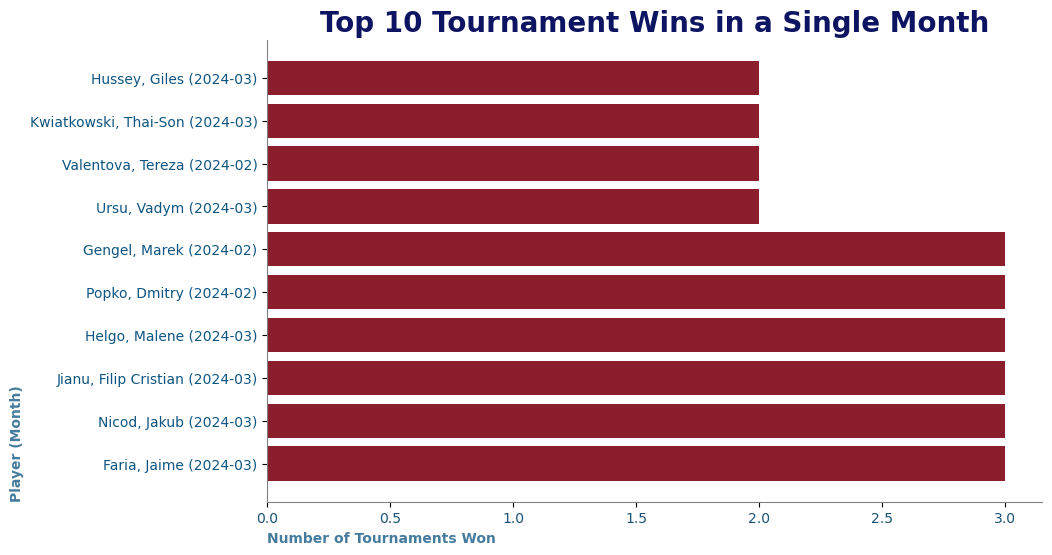

In [175]:
plt.figure(figsize=(10, 6))

plt.barh(
    top10["label"],
    top10["tournament_won"],color="#8B1E2D"
)

plt.xlabel("Number of Tournaments Won",loc="left",color="#457B9D",weight="bold")
plt.ylabel("Player (Month)",loc="bottom",color="#457B9D",weight="bold")
plt.title("Top 10 Tournament Wins in a Single Month",color="#0D1461",fontsize=20,weight="bold")
plt.xticks(color="#1A5275")
plt.yticks(color="#0E5581")
ax=plt.gca()
ax.spines[["top","right"]].set_visible(False)
ax.spines[["bottom","left"]].set_color("gray")

plt.show()

### Question Ten

In [4]:
h_players = MatchHomeTeamInfo[["player_id", "full_name", "height", "current_rank", "date"]].copy()
a_players = MatchAwayTeamInfo[["player_id", "full_name", "height", "current_rank", "date"]].copy()
players=pd.concat([h_players,a_players],ignore_index=True)
print("Row:",len(players))
print("unique players:",players["player_id"].nunique())

Row: 49813
unique players: 2644


we will probably have many more rows than unique players because players participate in multiple matches.

In [5]:
players["height"] = pd.to_numeric(players["height"],errors="coerce")
players["current_rank"] = pd.to_numeric(players["current_rank"],errors="coerce")
players["date"] = pd.to_datetime(players["date"])

In [6]:
players[["height","current_rank"]].isna().sum()

height          21952
current_rank      598
dtype: int64

This is important because players without height or ranking cannot be included in the correlation calculation.

In [ ]:
# Latest available height for each player
player_height = (
    players
    .dropna(subset=["height"])
    .sort_values(["player_id", "date"])
    .drop_duplicates("player_id", keep="last")
    [["player_id", "height"]]
)
# Latest available ranking for each player
player_rank = (
    players
    .dropna(subset=["current_rank"])
    .sort_values(["player_id", "date"])
    .drop_duplicates("player_id", keep="last")
    [["player_id", "current_rank"]]
)
players_corr = player_height.merge(
    player_rank,
    on="player_id",
    how="inner"
)
print("Rows:", len(players_corr))
print("Unique players:", players_corr["player_id"].nunique())

Rows: 1340
Unique players: 1340


In [14]:
players_corr

,player_id,height,current_rank
0,14414,1.83,122.0
1,14486,1.85,652.0
2,14548,1.83,70.0
3,14844,1.93,45.0
4,14882,1.88,1.0
...,...,...,...
1335,463772,1.93,1219.0
1336,464370,1.80,1159.0
1337,483188,1.88,897.0
1338,487577,1.78,1284.0


In [10]:
players_corr[["height", "current_rank"]].describe()

,height,current_rank
count,1340.000000,1340.000000
mean,1.822052,580.473134
std,0.080997,446.975387
min,1.570000,1.000000
25%,1.780000,193.750000
50%,1.830000,474.500000
75%,1.880000,899.000000
max,2.080000,1858.000000


In [12]:
correlation = players_corr["height"].corr(players_corr["current_rank"])
print("Correlation:", correlation)

Correlation: 0.10478103579162656


The Pearson correlation between player height and current ranking was approximately 0.105, indicating a very weak positive relationship. This suggests that player height has little linear association with ranking in this dataset.

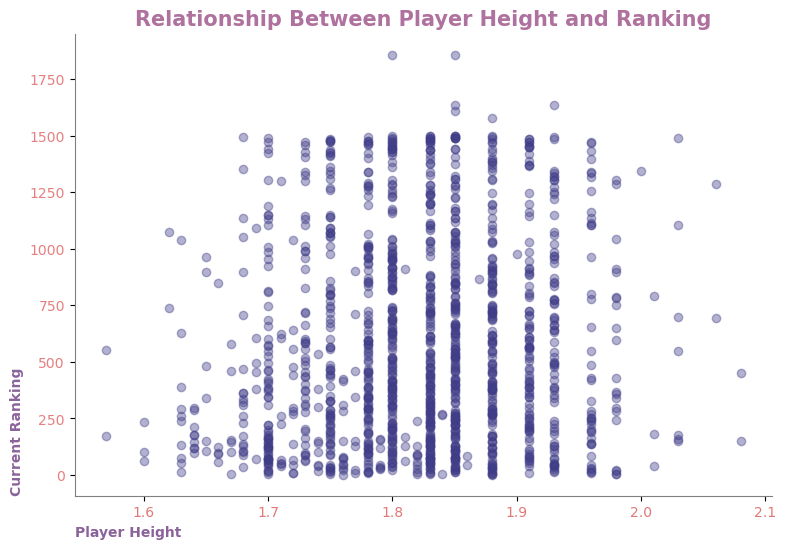

In [17]:
plt.figure(figsize=(9, 6))

plt.scatter(
    players_corr["height"],
    players_corr["current_rank"],
    alpha=0.4,
    color="#403D88"
)

plt.xlabel("Player Height",weight="bold",loc="left",color="#8B639B")
plt.ylabel("Current Ranking",weight="bold",loc="bottom",color="#8B639B")
plt.title("Relationship Between Player Height and Ranking",fontsize=15,color="#AF719D",weight="bold")
plt.xticks(color="#E27777")
plt.yticks(color="#E67F7F")
ax=plt.gca()
ax.spines[["top","right"]].set_visible(False)
ax.spines[["bottom","left"]].set_color("gray")

plt.show()

### Question Eleven

In [24]:
MatchTimeInfo[["period_1","period_2","period_3","period_4","period_5"]].describe()

,period_1,period_2,period_3
count,22576.000000,22471.000000,6886.000000
mean,2968.423990,3191.026568,3292.027157
std,6250.475337,6107.149799,6826.886790
min,2.000000,-16200.000000,0.000000
25%,2047.000000,2120.500000,1961.000000
50%,2521.000000,2610.000000,2608.000000
75%,3157.000000,3259.500000,3308.000000
max,172606.000000,169438.000000,152072.000000


A negative set duration is impossible.(172606 seconds ≈ 47.9 hours) for one set is clearly not a valid tennis set duration.

In [23]:
print("Rows:", len(MatchTimeInfo))
print("Unique matches:", MatchTimeInfo["match_id"].nunique())
print("Exact duplicate rows:", MatchTimeInfo.duplicated().sum())

Rows: 35671
Unique matches: 16873
Exact duplicate rows: 0


In [28]:
MatchTimeInfo["date"] = pd.to_datetime(MatchTimeInfo["date"])
time_final = (MatchTimeInfo.sort_values(["match_id","date"]).drop_duplicates("match_id",keep="last").copy())
period_cols = ["period_1","period_2","period_3","period_4","period_5"]
for col in period_cols:
    MatchTimeInfo[col] = pd.to_numeric(MatchTimeInfo[col],errors="coerce")
MatchTimeInfo[period_cols].stack().describe(percentiles=[0.90,0.95,0.99,0.995,0.999])

count     51933.000000
mean       3107.650184
std        6270.238413
min      -16200.000000
50%        2568.000000
90%        3941.000000
95%        4425.000000
99%        6498.000000
99.5%     19830.300000
99.9%     86430.000000
max      172606.000000
dtype: float64

In [30]:
invalid_period=((time_final[period_cols]<0)|(time_final[period_cols]>21600)).any(axis=1)
print("Matches with clearly invalid period values:",invalid_period.sum())

Matches with clearly invalid period values: 88


21600 seconds = 6 hours _ This is intentionally generous. We are not saying a set officially has a six-hour maximum. We are using it to separate obvious data errors such as 20–48 hour set durations from legitimate long matches.

In [32]:
time_clean = time_final[~invalid_period].copy()
time_clean["duration_seconds"] = (time_clean[period_cols].sum(axis=1, min_count=1))
time_clean["duration_minutes"] = (time_clean["duration_seconds"] / 60)
time_clean["duration_minutes"].describe(percentiles=[0.90, 0.95, 0.99, 0.995, 0.999])

count    11001.000000
mean       104.070607
std         38.903179
min          0.083333
50%         96.716667
90%        152.816667
95%        171.650000
99%        209.566667
99.5%      245.616667
99.9%      395.566667
max        606.050000
Name: duration_minutes, dtype: float64

In [ ]:
duration_final = time_clean[(time_clean["duration_minutes"] >= 10) &(time_clean["duration_minutes"] <= 360)].copy()
print("Before:", time_clean["duration_minutes"].notna().sum())
print("After:", len(duration_final))

Before: 11001
After: 10979


In [39]:
duration_final["duration_minutes"].describe(
    percentiles=[0.90, 0.95, 0.99]
)

count    10979.000000
mean       103.680032
std         36.483795
min         19.116667
50%         96.700000
90%        152.453333
95%        170.986667
99%        206.993333
max        355.633333
Name: duration_minutes, dtype: float64

In [41]:
average_duration = duration_final["duration_minutes"].mean()
print(f"Average match duration: {average_duration:.2f} minutes")
hours = int(average_duration // 60)
minutes = int(round(average_duration % 60))
print(f"Average match duration: "f"{hours} hour(s) and {minutes} minutes")

Average match duration: 103.68 minutes
Average match duration: 1 hour(s) and 44 minutes


The average match duration was approximately 103.68 minutes (about 1 hour and 44 minutes) among matches with available and usable duration data.After excluding clearly invalid duration records and matches with missing duration information, 10,979 matches were included in the analysis.

### Question Twelve

In [64]:
home_score = MatchHomeScoreInfo[["match_id", "date"] + period_cols].copy()
away_score = MatchAwayScoreInfo[["match_id", "date"] + period_cols].copy()
home_score = home_score.rename(columns={col: f"home_{col}" for col in period_cols})
away_score = away_score.rename(columns={col: f"away_{col}"for col in period_cols})
scores=home_score.merge(away_score,on=["match_id","date"],how="inner")
scores["date"]=pd.to_datetime(scores["date"])

In [65]:
scores_final = (scores.sort_values(["match_id", "date"]).drop_duplicates(subset="match_id",keep="last").copy())

print("Rows:", len(scores_final))
print("Unique matches:",scores_final["match_id"].nunique())

Rows: 16873
Unique matches: 16873


In [ ]:
home_gender = (MatchHomeTeamInfo[["match_id", "gender"]].dropna(subset=["gender"]).drop_duplicates().groupby("match_id", as_index=False)["gender"].first().rename(columns={"gender": "gender_home"}))
away_gender = (MatchAwayTeamInfo[["match_id", "gender"]].dropna(subset=["gender"]).drop_duplicates().groupby("match_id", as_index=False)["gender"].first().rename(columns={"gender": "gender_away"}))
gender_check = home_gender.merge(away_gender,on="match_id",how="outer")

In [68]:
for col in period_cols:
    scores_final[f"home_{col}"] = pd.to_numeric(scores_final[f"home_{col}"],errors="coerce")
    scores_final[f"away_{col}"] = pd.to_numeric(scores_final[f"away_{col}"],errors="coerce")

gender_check["gender"]=(gender_check["gender_home"].fillna(gender_check["gender_away"]))
match_gender=(gender_check[["match_id","gender"]].drop_duplicates("match_id"))
scores_final =scores_final.drop(columns=["gender"],errors="ignore")
scores_final = scores_final.merge(match_gender,on="match_id",how="left")
scores_final["gender"].value_counts(dropna=False)

gender
M      8228
F      5958
NaN    2687
Name: count, dtype: int64

After combining the gender information from the home and away player datasets and merging it with the match score data, **2,687 matches** still had missing gender values.

These missing values occur because no valid gender information was available for those `match_id`s in either the home-team or away-team data.

The score dataset contains **16,873 unique matches**, of which:

- **8,228 matches** were identified as men's matches (`M`)
- **5,958 matches** were identified as women's matches (`F`)
- **2,687 matches** had no available gender information

Because the missing gender values cannot be reliably inferred, these matches were excluded only from the gender-based comparison. The analysis of average games per set by gender was therefore performed using matches with known gender information only.

In [90]:
scores_gender = scores_final.dropna(subset=["gender"]).copy()
for col in period_cols:
    scores_final[f"games_{col}"] = (scores_final[f"home_{col}"] +scores_final[f"away_{col}"])

game_cols = [f"games_{col}"for col in period_cols]

sets = scores_final[["match_id", "gender"] + game_cols].melt(id_vars=["match_id", "gender"],value_vars=game_cols,var_name="set",value_name="games")  

sets_clean = sets.dropna(subset=["gender", "games"]).copy()
sets_clean = sets_clean[sets_clean["games"] > 0].copy()
sets_clean.sort_values("games",ascending=False).head(10)

,match_id,gender,set,games
35032,12041957,M,games_period_3,40.0
38180,12078777,M,games_period_3,32.0
41799,12121259,F,games_period_3,31.0
35125,12042582,M,games_period_3,30.0
42280,12123966,M,games_period_3,30.0
42090,12122156,M,games_period_3,29.0
41609,12120611,F,games_period_3,29.0
48933,12190437,M,games_period_3,28.0
34977,12041793,M,games_period_3,28.0
42155,12123672,F,games_period_3,27.0


In [78]:
result = (sets_clean.groupby("gender")["games"].agg(["count", "mean", "median", "std"]))
result

,count,mean,median,std
gender,,,,
F,13112,9.213850,9.0,2.482405
M,18041,9.594368,9.0,2.535224


Men's matches averaged 9.59 games per set, compared with 9.21 games per set in women's matches. Therefore, sets in men's matches were slightly longer in terms of games in this dataset.

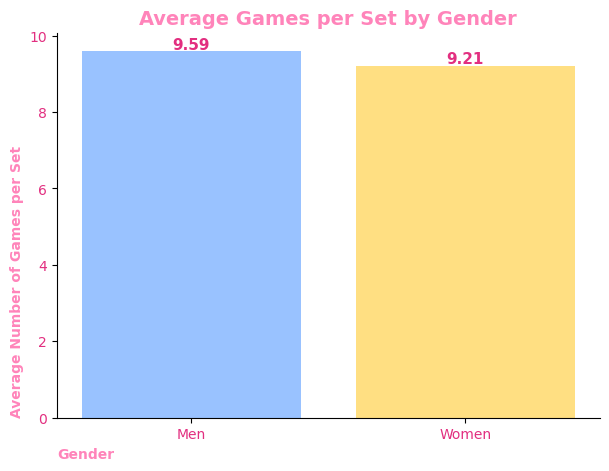

In [92]:

mean_games = result["mean"].reindex(["M", "F"])

plt.figure(figsize=(7, 5))

bars = plt.bar(
    ["Men", "Women"],
    mean_games.values,
    color=["#99C2FF", "#FFDF82"]
)

plt.xlabel("Gender",loc="left",weight="bold",color="#FF84BA")
plt.ylabel("Average Number of Games per Set",loc="bottom",weight="bold",color="#FF84BA")
plt.title(
    "Average Games per Set by Gender",
    fontsize=14,
    weight="bold",color="#FF84BA"
)
plt.xticks(color="#E22F80")
plt.yticks(color="#E22F80")

# Show the mean above each bar
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f"{bar.get_height():.2f}",
        ha="center",
        fontsize=11,
        weight="bold",color="#E22F80"
    )

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()